In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


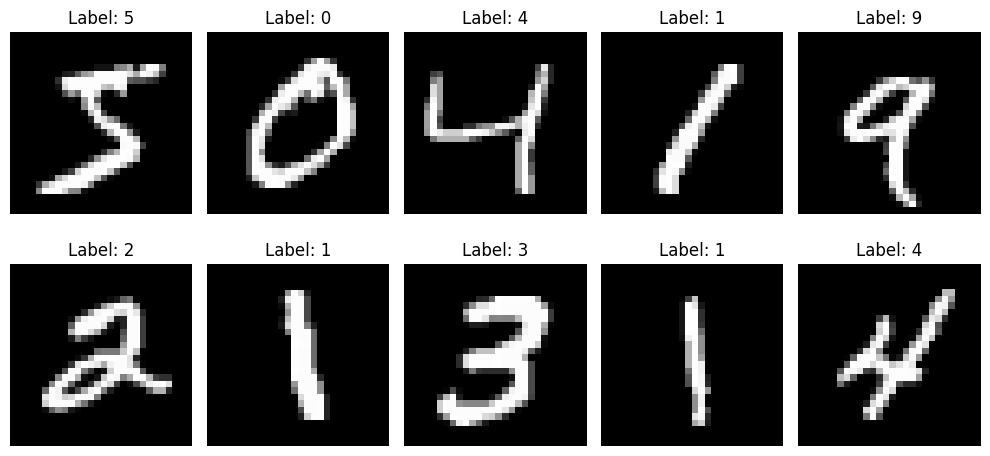

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (60000, 28, 28, 1)
Testing Data Shape: (10000, 28, 28, 1)


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.9128 - loss: 0.2837 - val_accuracy: 0.9850 - val_loss: 0.0528
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9694 - loss: 0.1037 - val_accuracy: 0.9880 - val_loss: 0.0390
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9788 - loss: 0.0718 - val_accuracy: 0.9900 - val_loss: 0.0359
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9825 - loss: 0.0572 - val_accuracy: 0.9918 - val_loss: 0.0303
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9856 - loss: 0.0483 - val_accuracy: 0.9897 - val_loss: 0.0351
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9876 - loss: 0.0418 - val_accuracy: 0.9923 - val_loss: 0.0302
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9888 - loss: 0.0356 - val_accuracy: 0.9912 - val_loss: 0.0306
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9899 - loss: 0.0320 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9932 - loss: 0.0220

Test Loss: 0.0220
Test Accuracy: 99.32%


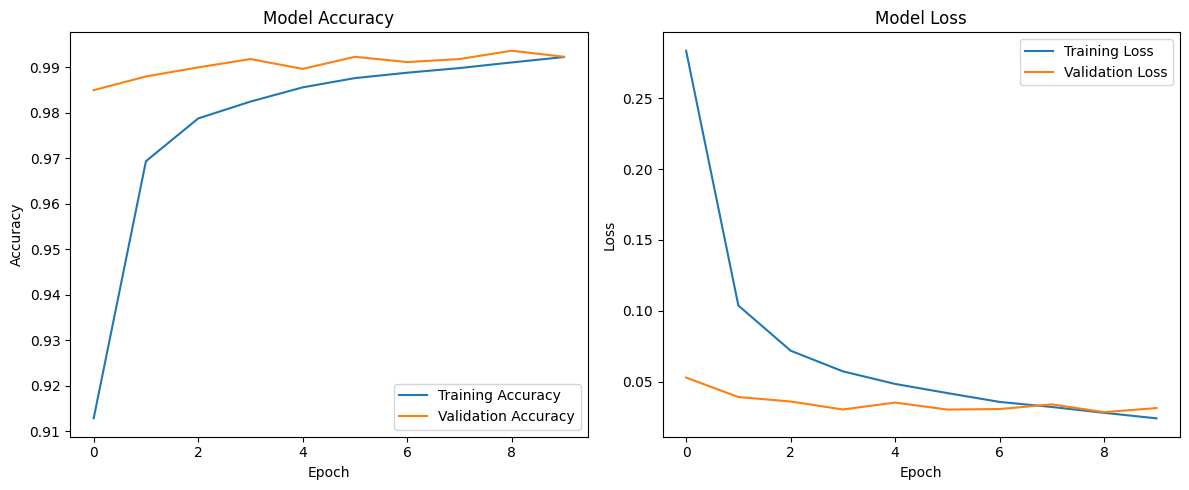

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Confusion Matrix:

[[ 975    1    0    0    0    0    1    2    1    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   2    1 1023    0    1    0    0    5    0    

In [ ]:
model.save("handwritten_character_recognition_model.h5")

print("Model saved successfully!")

Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


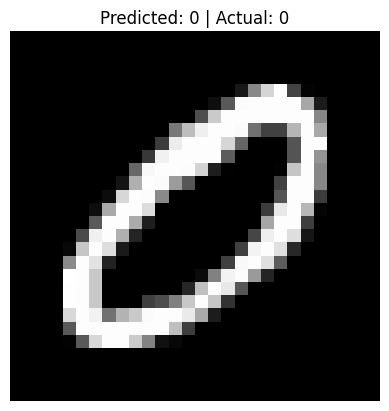

In [ ]:
index = np.random.randint(0, len(X_test))

image = X_test[index]
true_label = np.argmax(y_test[index])

prediction = model.predict(image.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label} | Actual: {true_label}")
plt.axis('off')
plt.show()

In [ ]:
accuracy = test_accuracy * 100

print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"Dataset              : MNIST")
print(f"Training Images      : {len(X_train)}")
print(f"Testing Images       : {len(X_test)}")
print(f"Model                : Convolutional Neural Network (CNN)")
print(f"Test Accuracy        : {accuracy:.2f}%")
print("=" * 50)

PROJECT SUMMARY
Dataset              : MNIST
Training Images      : 60000
Testing Images       : 10000
Model                : Convolutional Neural Network (CNN)
Test Accuracy        : 99.32%


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving my_digit.png to my_digit (3).png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


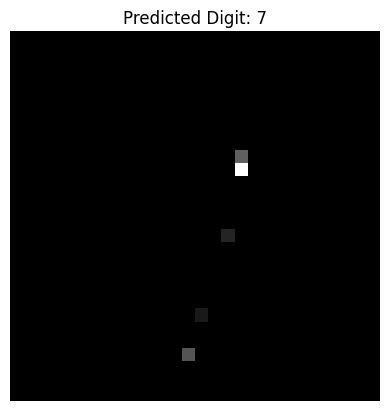

In [ ]:
filename = list(uploaded.keys())[0]

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
img = cv2.bitwise_not(img)
img = img.astype("float32") / 255.0
img = img.reshape(1, 28, 28, 1)

prediction = model.predict(img)
predicted_digit = np.argmax(prediction)

plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


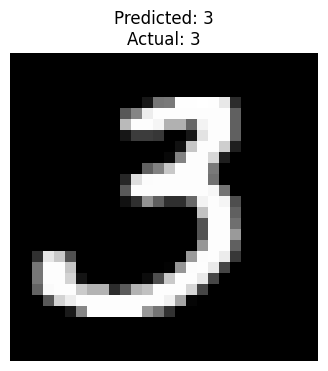

In [ ]:
import random

index = random.randint(0, len(X_test) - 1)

image = X_test[index].reshape(28, 28)
true_label = np.argmax(y_test[index])

prediction = model.predict(X_test[index].reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap='gray')
plt.title(f"Predicted: {predicted_label}\nActual: {true_label}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


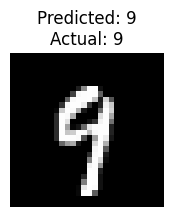

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


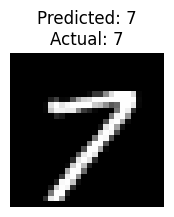

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


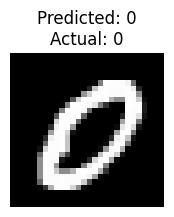

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


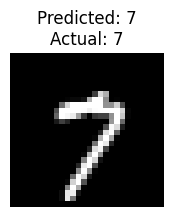

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


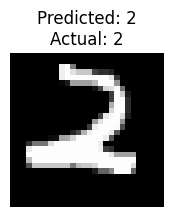

In [ ]:
for i in range(5):
    index = np.random.randint(0, len(X_test))

    image = X_test[index].reshape(28,28)
    actual = np.argmax(y_test[index])

    prediction = model.predict(X_test[index].reshape(1,28,28,1))
    predicted = np.argmax(prediction)

    plt.figure(figsize=(2,2))
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {predicted}\nActual: {actual}")
    plt.axis('off')
    plt.show()

In [ ]:
print("="*50)
print("HANDWRITTEN CHARACTER RECOGNITION USING CNN")
print("="*50)
print("Dataset           : MNIST")
print("Training Images   :", X_train.shape[0])
print("Testing Images    :", X_test.shape[0])
print("Image Size        : 28 x 28")
print("Number of Classes :", 10)
print(f"Test Accuracy     : {test_accuracy*100:.2f}%")
print("="*50)
print("Project Completed Successfully!")

HANDWRITTEN CHARACTER RECOGNITION USING CNN
Dataset           : MNIST
Training Images   : 60000
Testing Images    : 10000
Image Size        : 28 x 28
Number of Classes : 10
Test Accuracy     : 99.32%
Project Completed Successfully!


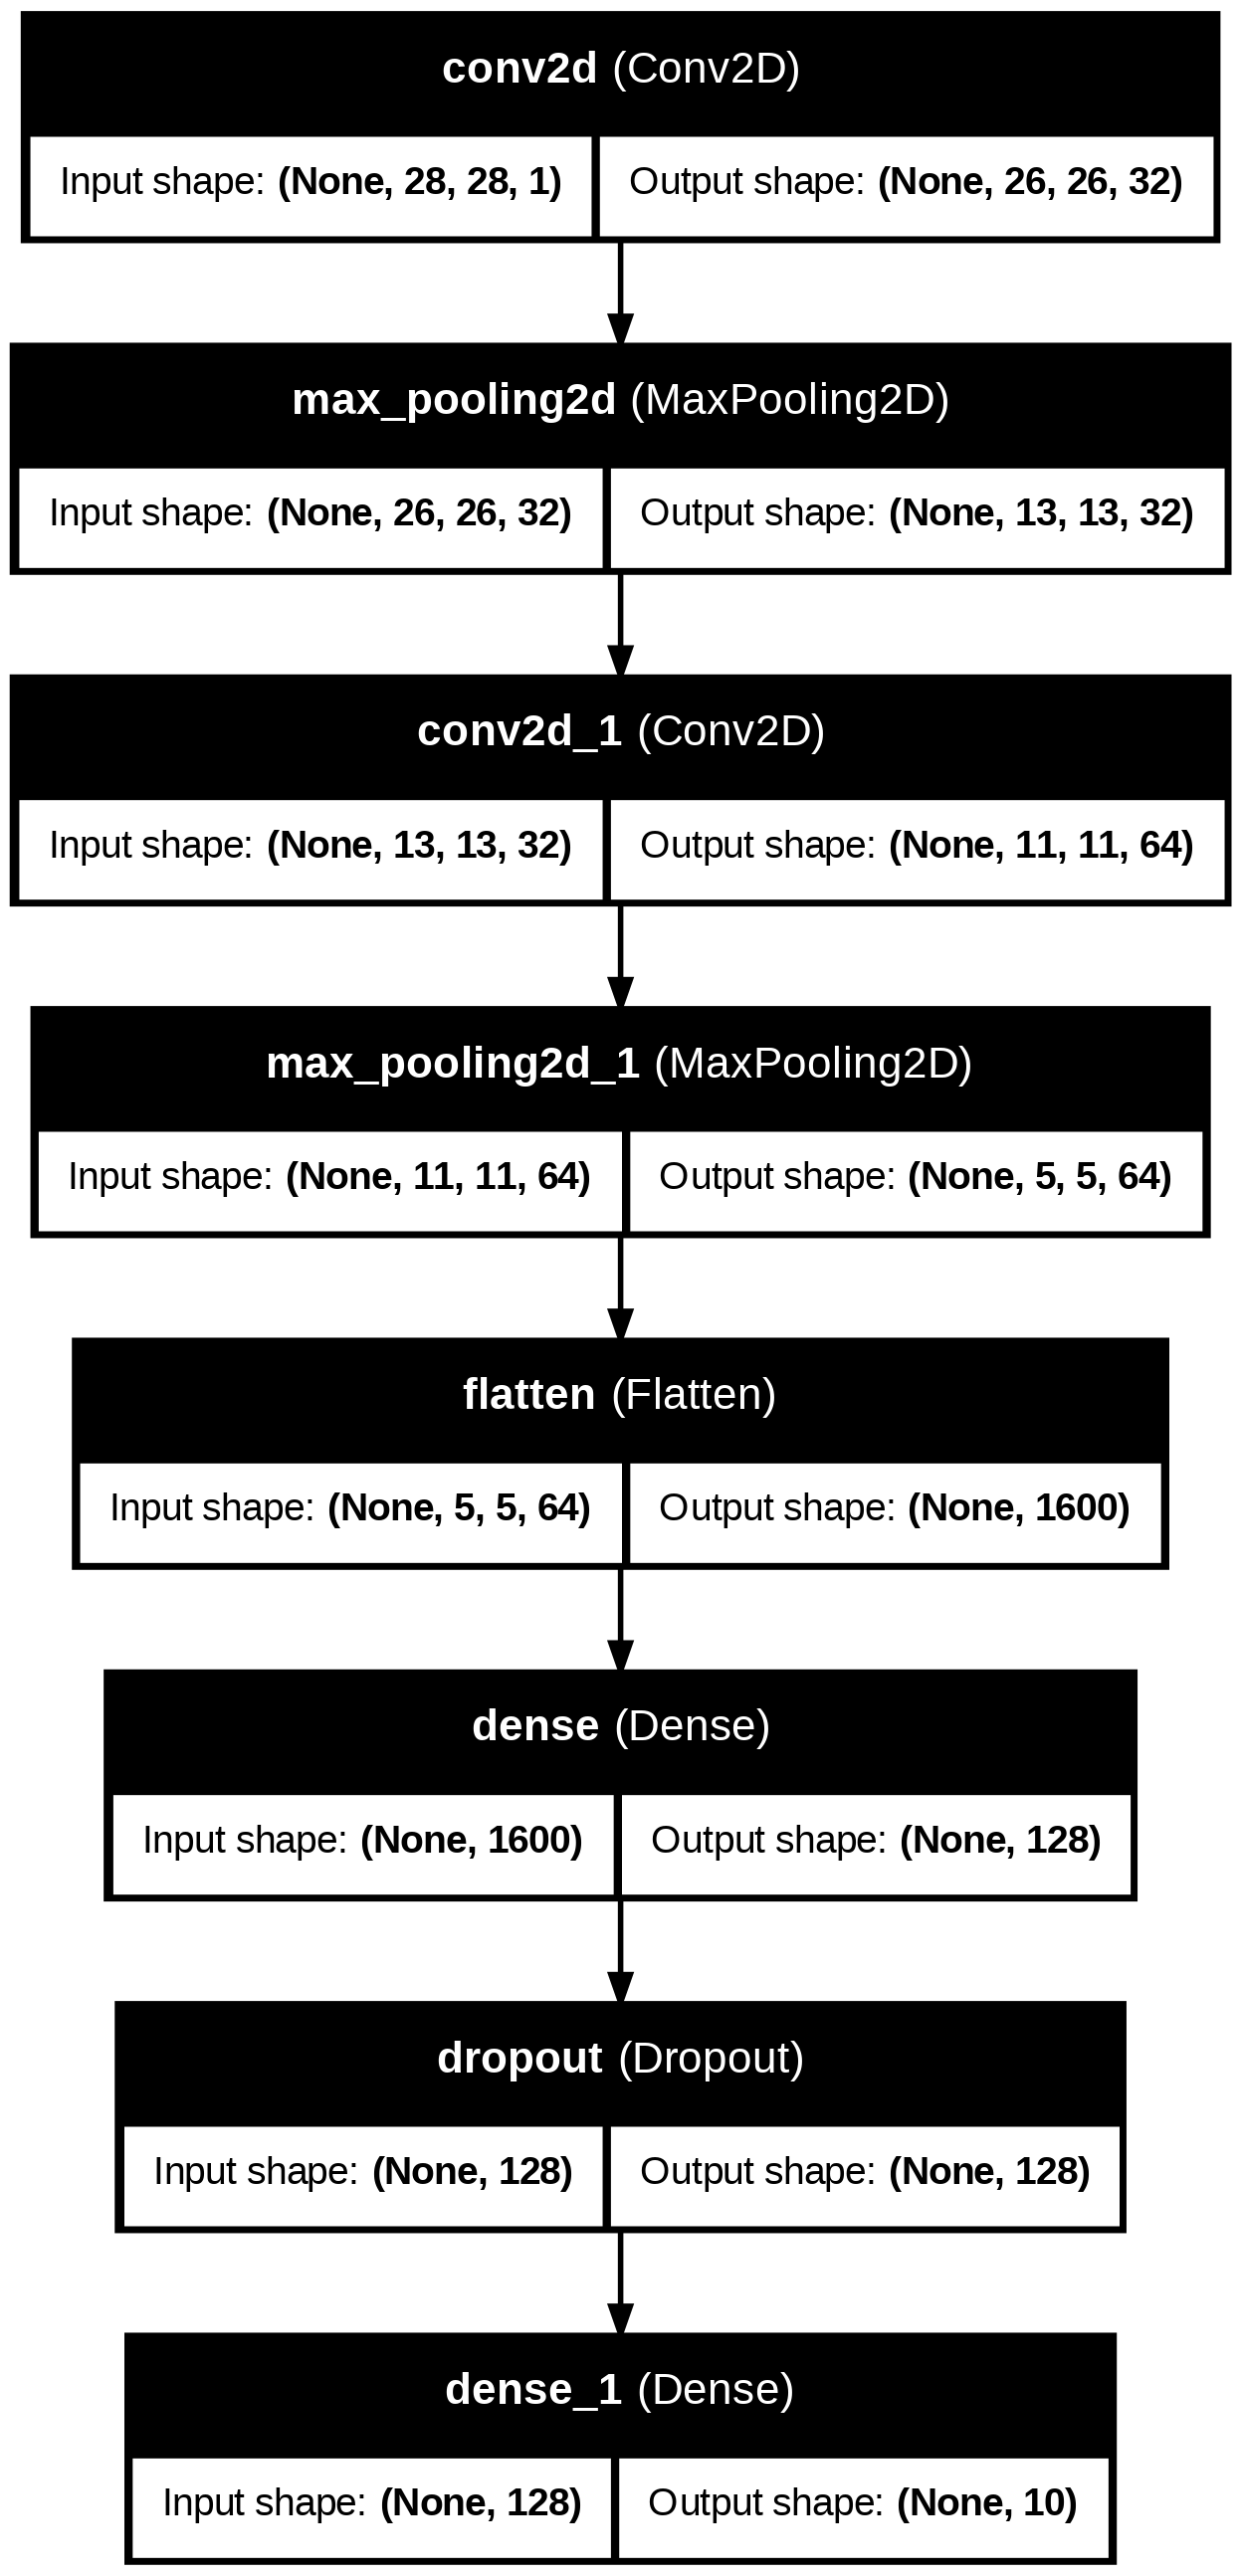

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    to_file="cnn_model.png"
)

from IPython.display import Image
Image("cnn_model.png")

In [ ]:
print(f"Training Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 99.23%
Validation Accuracy: 99.23%
Testing Accuracy: 99.32%


In [ ]:
from google.colab import files

files.download("handwritten_character_recognition_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

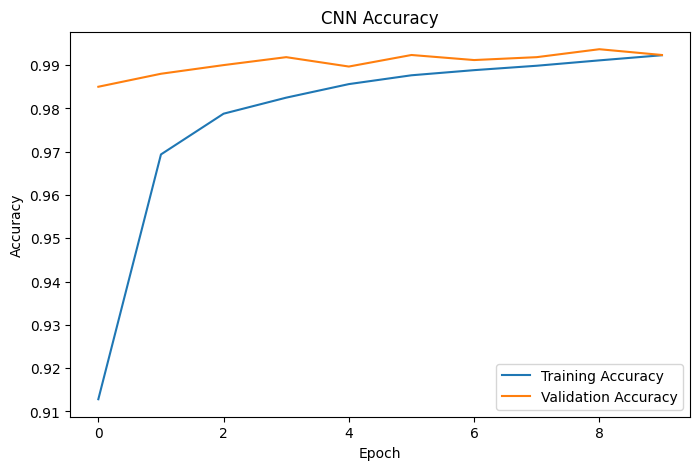

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Accuracy')
plt.savefig("accuracy_graph.png")
plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
from PIL import Image

In [ ]:
def predict_digit(image):
    image = image.convert("L")
    image = image.resize((28, 28))

    img = np.array(image)

    img = 255 - img

    img = img.astype("float32") / 255.0
    img = img.reshape(1, 28, 28, 1)

    prediction = model.predict(img)

    digit = np.argmax(prediction)
    confidence = np.max(prediction)

    return f"Predicted Digit: {digit}\nConfidence: {confidence:.2%}"

In [ ]:
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Handwritten Character Recognition",
    description="Upload a handwritten digit (0-9) and let the CNN predict it."
)

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7dbfd151cb8c250256.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
